# PM2.5 Prediction Model

**Input:** `df_model_monthly.csv` built in `features.ipynb`.

| Model | Algorithm | Features                                              | Goal |
|---|---|-------------------------------------------------------|---|
| **A** | RF + XGBoost | environmental, spatial, contextual variables          | Policy story: what can municipalities act on? |
| **B** | RF | PM2.5 lags, rolling features, lagged pollutants, weather, context | Accuracy benchmark |
| **C** | Ridge | Same as A                                             | Linear baseline with signed coefficients |

**Two splits:** time (train past / test future) and spatial (train on some stations / test on unseen stations).

**Output:** `datasets/part3_predictions.csv` and `datasets/part3_model_metrics.csv` → used by `part4_policy_translation.ipynb`.

In [12]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
from xgboost import XGBRegressor

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

print("Libraries loaded")

Libraries loaded


## Load final modeling dataset

This CSV was created in `features.ipynb` and already contains:
- date
- station identifier (`eoi_code`)
- weather/context variables
- lag features
- rolling features

For now, we only use the columns needed for Model A.

In [13]:
df = pd.read_csv("df_model_monthly.csv", parse_dates=["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Stations:", df["eoi_code"].nunique())

display(df.head())

Shape: (3986, 33)
Date range: 2020-01-01 00:00:00 to 2025-11-01 00:00:00
Stations: 144


,eoi_code,date,Year,Month,Season,PM2_5,PM10,NO2,O3,PM2_5_lag1,PM2_5_lag2,PM2_5_lag3,PM2_5_roll3_mean,PM2_5_roll3_std,PM10_lag1,NO2_lag1,O3_lag1,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Station_Type,Station_Area,City,Green_Ratio,Population_Density,month_sin,month_cos
0,IT0459A,2020-04-01,2020,4,Spring,8.32,21.4,24.4,54.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.490000,10.310000,44.6,NaN,NaN,NaN,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,8.660254e-01,-0.500000
1,IT0459A,2020-05-01,2020,5,Spring,6.41,19.7,25.1,56.7,8.32,NaN,NaN,NaN,NaN,21.4,24.4,54.1,18.061290,10.125806,62.0,13.490000,10.310000,44.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,5.000000e-01,-0.866025
2,IT0459A,2020-06-01,2020,6,Summer,8.42,21.6,23.9,61.4,6.41,8.32,NaN,NaN,NaN,19.7,25.1,56.7,21.836667,9.896667,59.2,18.061290,10.125806,62.0,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,1.224647e-16,-1.000000
3,IT0459A,2020-07-01,2020,7,Summer,8.13,20.4,20.1,56.5,8.42,6.41,8.32,7.716667,1.132711,21.6,23.9,61.4,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-5.000000e-01,-0.866025
4,IT0459A,2020-08-01,2020,8,Summer,7.74,20.0,27.2,53.0,8.13,8.42,6.41,7.653333,1.086477,20.4,20.1,56.5,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-8.660254e-01,-0.500000


In [14]:
# Ensuring target exists, date is datetime, station id exists, PM2.5 has non-missing values
print("Target missing:", df["PM2_5"].isna().sum())
print("Date dtype:", df["date"].dtype)
print("Station id missing:", df["eoi_code"].isna().sum())

display(df[["date", "eoi_code", "PM2_5"]].head())

Target missing: 0
Date dtype: datetime64[ns]
Station id missing: 0


,date,eoi_code,PM2_5
0,2020-04-01,IT0459A,8.32
1,2020-05-01,IT0459A,6.41
2,2020-06-01,IT0459A,8.42
3,2020-07-01,IT0459A,8.13
4,2020-08-01,IT0459A,7.74


## Modeling dataset and splits

Before building individual models, we create one shared modeling dataset and one shared split setup.

This keeps Models A, B, and C fully comparable:
- same rows
- same target
- same station grouping
- same time split
- same spatial split

Filtering only on PM2.5 history features required by the forecasting setup.
We do not filter on pollutant lags like O3, because those reflect real sensor availability and would remove too many observations.

In [15]:
required_history = [
    "PM2_5_lag1",
    "PM2_5_lag2",
    "PM2_5_lag3",
    "PM2_5_roll3_mean",
    "PM2_5_roll3_std"
]

df_model = df.dropna(subset=required_history).copy()

print("Rows before filtering:", len(df))
print("Rows after common history filter:", len(df_model))
print("Stations after filter:", df_model["eoi_code"].nunique())

display(df_model.head())

Rows before filtering: 3986
Rows after common history filter: 3554
Stations after filter: 114


,eoi_code,date,Year,Month,Season,PM2_5,PM10,NO2,O3,PM2_5_lag1,PM2_5_lag2,PM2_5_lag3,PM2_5_roll3_mean,PM2_5_roll3_std,PM10_lag1,NO2_lag1,O3_lag1,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Station_Type,Station_Area,City,Green_Ratio,Population_Density,month_sin,month_cos
3,IT0459A,2020-07-01,2020,7,Summer,8.13,20.4,20.1,56.5,8.42,6.41,8.32,7.716667,1.132711,21.6,23.9,61.4,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.500000,-8.660254e-01
4,IT0459A,2020-08-01,2020,8,Summer,7.74,20.0,27.2,53.0,8.13,8.42,6.41,7.653333,1.086477,20.4,20.1,56.5,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.866025,-5.000000e-01
5,IT0459A,2020-09-01,2020,9,Autumn,7.20,16.9,28.6,35.6,7.74,8.13,8.42,8.096667,0.341223,20.0,27.2,53.0,20.910000,9.833333,57.8,25.606452,10.080645,65.2,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-1.000000,-1.836970e-16
6,IT0459A,2020-10-01,2020,10,Autumn,24.90,36.4,29.3,26.0,7.20,7.74,8.13,7.690000,0.467012,16.9,28.6,35.6,14.580645,8.735484,52.8,20.910000,9.833333,57.8,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.866025,5.000000e-01
7,IT0459A,2020-11-01,2020,11,Autumn,18.40,26.5,26.3,29.1,24.90,7.20,7.74,13.280000,10.066837,36.4,29.3,26.0,11.090000,9.396667,48.7,14.580645,8.735484,52.8,15.0,43.5989,13.3419,Background,Suburban,Chiaravalle,0.813059,788.0,-0.500000,8.660254e-01


## Target and grouping variable

These objects will be reused by all models:
- `y` = PM2.5 target
- `groups` = station identifier for spatial split

In [16]:
target_col = "PM2_5"
y = df_model[target_col].copy()
groups = df_model["eoi_code"].copy()

print("Filtered modeling shape:", df_model.shape)
print("Target shape:", y.shape)
print("Unique stations:", groups.nunique())

Filtered modeling shape: (3554, 33)
Target shape: (3554,)
Unique stations: 114


## Common train/test splits

We define the split and reuse it for all models.

### Time split
Train on earlier months, test on later months

In [17]:
# Time split
cutoff_date = df_model["date"].quantile(0.8)
time_train_mask = df_model["date"] <= cutoff_date
time_test_mask = df_model["date"] > cutoff_date

print("Cutoff:", cutoff_date.date())
print("Train/test:", time_train_mask.sum(), time_test_mask.sum())

Cutoff: 2025-04-01
Train/test: 2885 669


### Spatial split
Train on some stations, test on unseen stations

In [18]:
# Spatial split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, te_idx = next(splitter.split(df_model, y, groups=groups))

print("Spatial train/test rows:", len(tr_idx), len(te_idx))
print("Train stations:", df_model.iloc[tr_idx]["eoi_code"].nunique())
print("Test stations:", df_model.iloc[te_idx]["eoi_code"].nunique())

Spatial train/test rows: 2831 723
Train stations: 91
Test stations: 23


## Model A — RF + XGBoost (Explanatory)

### ⚠️ TO BUILD

Train RF and XGBoost on `features_a`. Pick champion by lowest average RMSE across both splits.

**Data ready to use:**
- `X_a` — built below
- `y`, `groups`, `time_train_mask`, `time_test_mask`, `tr_idx`, `te_idx` — shared from setup above
- `pre_a` — preprocessor built below

**XGBoost params:** `n_estimators=400, learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0`

**RF params:** `n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1`

**Variable names needed by comparison cell:**
- `pred_champ_a_t`, `pred_champ_a_s` — champion predictions on time/spatial test
- `m_champ_a_t`, `m_champ_a_s` — metrics dicts
- `champion_a_name` — string: `"RF"` or `"XGBoost"`
- `champ_a_full` — model retrained on full dataset (for SHAP / feature importance)

In [19]:
# Model A feature set
# Keep this list simple and explicit.
# If a column name does not exist in df_model, it will be skipped safely.

candidate_features_a = [
    # Seasonality
    "Season",
    "month_sin",
    "month_cos",

    # Weather
    "Temp_Mean",
    "Wind_Speed",
    "Precipitation",

    # Lagged weather (still okay for explanatory model)
    "Temp_Mean_lag1",
    "Wind_Speed_lag1",
    "Precipitation_lag1",

    # Spatial
    "Altitude",
    "Latitude",
    "Longitude",
    "Green_Ratio",
    "Population_Density",

    # Contextual / station metadata
    "Station_Type",
    "Station_Area",
    "City"
]

features_a = [c for c in candidate_features_a if c in df_model.columns]

print("Model A features:", len(features_a))
print(features_a)


Model A features: 17
['Season', 'month_sin', 'month_cos', 'Temp_Mean', 'Wind_Speed', 'Precipitation', 'Temp_Mean_lag1', 'Wind_Speed_lag1', 'Precipitation_lag1', 'Altitude', 'Latitude', 'Longitude', 'Green_Ratio', 'Population_Density', 'Station_Type', 'Station_Area', 'City']


In [20]:
def make_preprocessor(feature_list):
    num_cols = [c for c in feature_list if pd.api.types.is_numeric_dtype(df_model[c])]
    cat_cols = [c for c in feature_list if c not in num_cols]
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot",  OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ])

def reg_metrics(y_true, y_pred):
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2":   r2_score(y_true, y_pred),
    }

pre_a = make_preprocessor(features_a)
print("Preprocessors and metrics helper ready")

Preprocessors and metrics helper ready


### Build Model A feature matrix

We now create the feature matrix for Model A only.

Important:
- `y` is already shared
- split masks and indices are already shared
- only `X_a` is model-specific

In [21]:
X_a = df_model[features_a].copy()

print("Model A X shape:", X_a.shape)
display(X_a.head())

# Reminder:
# y, groups, time_train_mask, time_test_mask, tr_idx, te_idx
# were already created in the shared setup section above.

Model A X shape: (3554, 17)


,Season,month_sin,month_cos,Temp_Mean,Wind_Speed,Precipitation,Temp_Mean_lag1,Wind_Speed_lag1,Precipitation_lag1,Altitude,Latitude,Longitude,Green_Ratio,Population_Density,Station_Type,Station_Area,City
3,Summer,-0.500000,-8.660254e-01,24.532258,9.580645,28.6,21.836667,9.896667,59.2,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
4,Summer,-0.866025,-5.000000e-01,25.606452,10.080645,65.2,24.532258,9.580645,28.6,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
5,Autumn,-1.000000,-1.836970e-16,20.910000,9.833333,57.8,25.606452,10.080645,65.2,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
6,Autumn,-0.866025,5.000000e-01,14.580645,8.735484,52.8,20.910000,9.833333,57.8,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle
7,Autumn,-0.500000,8.660254e-01,11.090000,9.396667,48.7,14.580645,8.735484,52.8,15.0,43.5989,13.3419,0.813059,788.0,Background,Suburban,Chiaravalle


### Model A — Time split

The dataset is divided based on the date:
- the model is trained on **earlier months**
- the model is tested on **later months**

This simulates a realistic forecasting scenario, where we use past data to predict future air pollution levels.

We train both:
- Random Forest (RF)
- XGBoost (XGB)

and compare their performance using MAE, RMSE, and R².

In [26]:
# ── Time split data ─────────────────────────────────────────
X_train_a_t = X_a.loc[time_train_mask] # Features for training(past data)
X_test_a_t  = X_a.loc[time_test_mask] # Features for testing (future data)
y_train_t   = y.loc[time_train_mask] # values for training
y_test_t    = y.loc[time_test_mask] # values for testing

# ── RF — time split ─────────────────────────────────────────
#Build Pipeline: Preprocessig + RF

rf_a_t = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
])
#Train model on past data
rf_a_t.fit(X_train_a_t, y_train_t)
pred_rf_a_t = rf_a_t.predict(X_test_a_t) #Predict PM2.5 on future data
m_rf_a_t    = reg_metrics(y_test_t, pred_rf_a_t) #Evaluate predictions using MAE, RMSE, and R²
print("RF   time split:", m_rf_a_t)

# ── XGBoost — time split ────────────────────────────────────
# Same process as RF
xgb_a_t = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )),
])
xgb_a_t.fit(X_train_a_t, y_train_t)
pred_xgb_a_t = xgb_a_t.predict(X_test_a_t)
m_xgb_a_t    = reg_metrics(y_test_t, pred_xgb_a_t)

print("XGB  time split:", m_xgb_a_t)

RF   time split: {'MAE': 4.4903809638683585, 'RMSE': 10.596677612023408, 'R2': 0.271419286709065}
XGB  time split: {'MAE': 4.300732194772786, 'RMSE': 10.45153322716824, 'R2': 0.29124156876584895}


### Model A — Spatial split

Instead of splitting the data by time, we split it by **monitoring stations** (`eoi_code`).

- the model is trained on data from a subset of stations
- the model is tested on **completely unseen stations**

We train both:
- Random Forest(RF)
- XGBoost(XGB)

In [23]:
# ── Spatial split data ──────────────────────────────────────
# Split the dataset using indices created earlier (GroupShuffleSplit)
# Ensures that train and test contain DIFFERENT stations

X_train_a_s = X_a.iloc[tr_idx] # Features for training (some stations)
X_test_a_s = X_a.iloc[te_idx] # Features for testing (unseen stations)
y_train_s = y.iloc[tr_idx] #
y_test_s = y.iloc[te_idx]

# ── RF — spatial split ──────────────────────────────────────
rf_a_s = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
])
rf_a_s.fit(X_train_a_s, y_train_s)
pred_rf_a_s = rf_a_s.predict(X_test_a_s)
m_rf_a_s = reg_metrics(y_test_s, pred_rf_a_s)
print("RF   spatial split:", m_rf_a_s)

# ── XGBoost — spatial split ─────────────────────────────────
xgb_a_s = Pipeline([
    ("preprocess", clone(pre_a)),
    ("model", XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )),
])
xgb_a_s.fit(X_train_a_s, y_train_s)
pred_xgb_a_s = xgb_a_s.predict(X_test_a_s)
m_xgb_a_s = reg_metrics(y_test_s, pred_xgb_a_s)
print("XGB  spatial split:", m_xgb_a_s)


RF   spatial split: {'MAE': 3.773664335750437, 'RMSE': 5.680151171553054, 'R2': 0.5292062441946022}
XGB  spatial split: {'MAE': 3.8710580920539948, 'RMSE': 5.799940579539322, 'R2': 0.5091396030869171}


### Model A — Model Selection

Pick the model with the lowest average RMSE across both splits.

In [24]:
# ── Champion selection by lowest avg RMSE across both splits ─
avg_rmse_rf = (m_rf_a_t["RMSE"] + m_rf_a_s["RMSE"]) / 2
avg_rmse_xgb = (m_xgb_a_t["RMSE"] + m_xgb_a_s["RMSE"]) / 2

print(f"RF   avg RMSE: {avg_rmse_rf:.4f}")
print(f"XGB  avg RMSE: {avg_rmse_xgb:.4f}")

if avg_rmse_rf <= avg_rmse_xgb:
    champion_a_name = "RF"
    pred_champ_a_t = pred_rf_a_t
    pred_champ_a_s = pred_rf_a_s
    m_champ_a_t = m_rf_a_t
    m_champ_a_s = m_rf_a_s
else:
    champion_a_name = "XGBoost"
    pred_champ_a_t = pred_xgb_a_t
    pred_champ_a_s = pred_xgb_a_s
    m_champ_a_t = m_xgb_a_t
    m_champ_a_s = m_xgb_a_s

print(f"\nChampion A: {champion_a_name}")
print(f"  Time split   → RMSE={m_champ_a_t['RMSE']:.4f}  MAE={m_champ_a_t['MAE']:.4f}  R2={m_champ_a_t['R2']:.4f}")
print(f"  Spatial split → RMSE={m_champ_a_s['RMSE']:.4f}  MAE={m_champ_a_s['MAE']:.4f}  R2={m_champ_a_s['R2']:.4f}")

# ── Retrain champion on FULL dataset (for SHAP / feature importance) ─
if champion_a_name == "RF":
    champ_a_full = Pipeline([
        ("preprocess", clone(pre_a)),
        ("model", RandomForestRegressor(
            n_estimators=400, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )),
    ])
else:
    champ_a_full = Pipeline([
        ("preprocess", clone(pre_a)),
        ("model", XGBRegressor(
            n_estimators=400, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbosity=0
        )),
    ])

champ_a_full.fit(X_a, y)
print(f"\nchamp_a_full retrained on full dataset ({len(X_a)} rows).")


RF   avg RMSE: 8.1384
XGB  avg RMSE: 8.1257

Champion A: XGBoost
  Time split   → RMSE=10.4515  MAE=4.3007  R2=0.2912
  Spatial split → RMSE=5.7999  MAE=3.8711  R2=0.5091

champ_a_full retrained on full dataset (3554 rows).


### Model A — Summary table

In [47]:
metrics_a = pd.DataFrame([
    {"split": "time", "model": f"RF_A", **m_rf_a_t},
    {"split": "spatial", "model": f"RF_A", **m_rf_a_s},
    {"split": "time", "model": f"XGBoost_A", **m_xgb_a_t},
    {"split": "spatial", "model": f"XGBoost_A", **m_xgb_a_s},
])
display(metrics_a)
metrics_a.to_csv("model_output/model_a_metrics.csv", index=False)
print(f"Champion: {champion_a_name}")


,split,model,MAE,RMSE,R2
0,time,RF_A,4.490381,10.596678,0.271419
1,spatial,RF_A,3.773664,5.680151,0.529206
2,time,XGBoost_A,4.300732,10.451533,0.291242
3,spatial,XGBoost_A,3.871058,5.799941,0.509140


Champion: XGBoost


### Model A — Performance Comparison (RF vs XGBoost

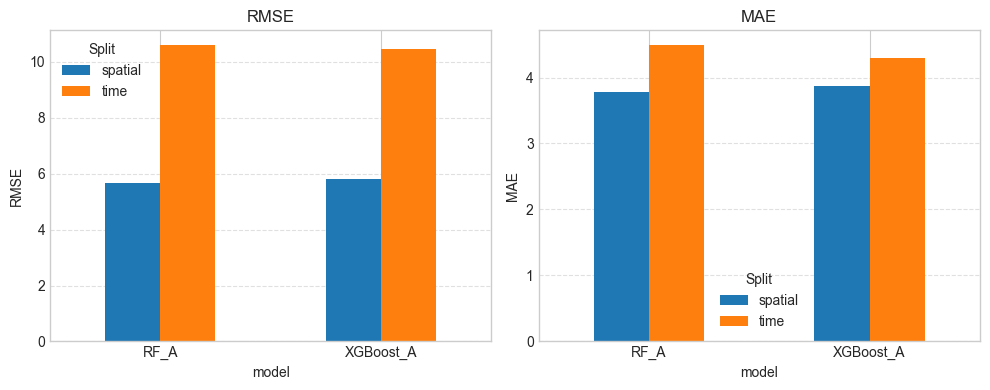

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric in zip(axes, ["RMSE", "MAE"]):

    # Pivot table: models vs splits
    plot_df = metrics_a.pivot(index="model", columns="split", values=metric)

    plot_df.plot(kind="bar", ax=ax, rot=0)

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.legend(title="Split")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("images/modela_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Model B — Random Forest (Environmental + PM2.5 History + Lagged Pollutants)

Accuracy benchmark. Adds PM2.5 lags, rolling stats, and lagged co-pollutants on top of all Model A features.
Comparing A vs B shows how much pollution memory and co-pollutant history improves forecasting.

In [43]:
# Model B feature set
features_b = [
    "PM2_5_lag1", "PM2_5_lag2", "PM2_5_lag3", "PM2_5_roll3_mean", "PM2_5_roll3_std",
    "PM10_lag1", "NO2_lag1", "O3_lag1",
    "Temp_Mean", "Wind_Speed", "Precipitation",
    "Temp_Mean_lag1", "Wind_Speed_lag1", "Precipitation_lag1",
    "month_sin", "month_cos",
    "Altitude", "Latitude", "Longitude",
    "Green_Ratio", "Population_Density",
    "Station_Type", "Station_Area",
]
features_b = [c for c in features_b if c in df_model.columns]
X_b = df_model[features_b].copy()
pre_b = make_preprocessor(features_b)

print("Model B features:", len(features_b))
print(features_b)

Model B features: 23
['PM2_5_lag1', 'PM2_5_lag2', 'PM2_5_lag3', 'PM2_5_roll3_mean', 'PM2_5_roll3_std', 'PM10_lag1', 'NO2_lag1', 'O3_lag1', 'Temp_Mean', 'Wind_Speed', 'Precipitation', 'Temp_Mean_lag1', 'Wind_Speed_lag1', 'Precipitation_lag1', 'month_sin', 'month_cos', 'Altitude', 'Latitude', 'Longitude', 'Green_Ratio', 'Population_Density', 'Station_Type', 'Station_Area']


### Model B — Time split

In [44]:
X_train_b_t = X_b.loc[time_train_mask]
X_test_b_t = X_b.loc[time_test_mask]
y_train_t = y.loc[time_train_mask]
y_test_t = y.loc[time_test_mask]

rf_b = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b.fit(X_train_b_t, y_train_t)
pred_rf_b_t = rf_b.predict(X_test_b_t)
m_rf_b_t = reg_metrics(y_test_t, pred_rf_b_t)
print("Model B time split:", m_rf_b_t)

Model B time split: {'MAE': 4.30533506617085, 'RMSE': 10.462300591489603, 'R2': 0.28978046423405146}


### Model B — Spatial split

In [ ]:
X_train_b_s = X_b.iloc[tr_idx]
X_test_b_s = X_b.iloc[te_idx]
y_train_s = y.iloc[tr_idx]
y_test_s = y.iloc[te_idx]

rf_b_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_s.fit(X_train_b_s, y_train_s)
pred_rf_b_s = rf_b_s.predict(X_test_b_s)
m_rf_b_s = reg_metrics(y_test_s, pred_rf_b_s)
print("Model B spatial split:", m_rf_b_s)

In [ ]:
metrics_b = pd.DataFrame([
    {"split": "time",    "model": "RandomForest_B", **m_rf_b_t},
    {"split": "spatial", "model": "RandomForest_B", **m_rf_b_s},
])
display(metrics_b)
metrics_b.to_csv("model_output/modelb_results.csv", index=False)
print("Saved to model_output/modelb_results.csv")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["RMSE", "MAE"]):
    metrics_b.pivot(index="model", columns="split", values=metric).plot(kind="bar", ax=ax, rot=0)
    ax.set_title(metric)
    ax.legend(title="split")
plt.tight_layout()
plt.savefig("images/modelb_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
r = y_test_t.values - pred_rf_b_t
axes.hist(r, bins=30, color="steelblue", edgecolor="white")
axes.axvline(0, color="black", linestyle="--")
axes.set_title("Model B residuals (time test)")
axes.set_xlabel("actual - pred")
plt.tight_layout()
plt.savefig("images/modelb_residuals_time.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
r = y_test_s.values - pred_rf_b_s
axes.hist(r, bins=30, color="steelblue", edgecolor="white")
axes.axvline(0, color="black", linestyle="--")
axes.set_title("Model B residuals (time test)")
axes.set_xlabel("actual - pred")
plt.tight_layout()
plt.savefig("images/modelb_residuals_space.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
names = rf_b.named_steps["preprocess"].get_feature_names_out()
imp = pd.Series(rf_b.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp.sort_values().plot(kind="barh", color="darkgreen")
plt.title("Model B RF — top 15 feature importances")
plt.tight_layout()
plt.savefig("images/modelb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
import scipy.sparse as sp
import shap

rf_b_full = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=42, n_jobs=-1)),
])
rf_b_full.fit(X_b, y)

Xp = rf_b_full.named_steps["preprocess"].transform(X_b)
if sp.issparse(Xp):
    Xp = Xp.toarray()
Xp = np.asarray(Xp, dtype=np.float64)

rng = np.random.RandomState(42)
idx = rng.choice(Xp.shape[0], size=min(800, Xp.shape[0]), replace=False)
Xs = Xp[idx]

explainer = shap.TreeExplainer(rf_b_full.named_steps["model"])
sv = explainer.shap_values(Xs)
fn = rf_b_full.named_steps["preprocess"].get_feature_names_out()

shap.summary_plot(sv, Xs, feature_names=fn, show=False)
plt.title("SHAP — Model B (RF, full dataset)")
plt.tight_layout()
plt.savefig("images/modelb_shap.png", dpi=150, bbox_inches="tight")
plt.show()

## Model C — Ridge Regression (Linear Baseline)

Same features as Model B. Ridge gives signed coefficients — positive = increases PM2.5, negative = decreases it.
Used to validate Model B SHAP directions with a simpler interpretable model.

In [ ]:
# Time split
ridge = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge.fit(X_train_b_t, y_train_t)
pred_ridge_t = ridge.predict(X_test_b_t)
m_ridge_t = reg_metrics(y_test_t, pred_ridge_t)
print("Model C (Ridge) time split:", m_ridge_t)

# Spatial split
ridge_s = Pipeline([
    ("preprocess", clone(pre_b)),
    ("model", Ridge(alpha=1.0, random_state=42)),
])
ridge_s.fit(X_train_b_s, y_train_s)
pred_ridge_s = ridge_s.predict(X_test_b_s)
m_ridge_s = reg_metrics(y_test_s, pred_ridge_s)
print("Model C (Ridge) spatial split:", m_ridge_s)

### Ridge Coefficients

In [ ]:
feat_names_c = ridge.named_steps["preprocess"].get_feature_names_out()
coef = pd.Series(
    ridge.named_steps["model"].coef_, index=feat_names_c
).sort_values(key=abs, ascending=False).head(15)

colors = ["#d73027" if v > 0 else "#4575b4" for v in coef.sort_values().values]
plt.figure(figsize=(9, 6))
coef.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Model C (Ridge) — Top 15 Coefficients\n(red = increases PM2.5 | blue = decreases)")
plt.tight_layout()
plt.savefig("images/model_c_ridge_coeff.png", dpi=150, bbox_inches="tight")
plt.show()